# Alpha-Seeker: Exploratory Data Analysis & Preprocessing
**CS 410 — Text Information Systems, Spring 2026**

This notebook performs EDA and preprocessing on our collected Reddit data to generate figures and stats for the milestone report.

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

FIGURE_DIR = '../reports'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150

print('Setup complete.')

Setup complete.


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>


## 2. Load Raw Data

In [2]:
df = pd.read_csv('../data/raw/reddit_posts_322_329.csv')

# Parse dates and create useful columns
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
df['year_month'] = df['created_date'].dt.to_period('M')
df['selftext'] = df['selftext'].fillna('')
df['title'] = df['title'].fillna('')
df['full_text'] = df['title'] + ' ' + df['selftext']
df['word_count'] = df['full_text'].str.split().str.len()

print(f'Loaded {len(df)} posts')
df.head()

Loaded 645 posts


,id,subreddit,title,selftext,author,created_utc,created_date,score,num_comments,url,link_flair_text,over_18,search_keyword,year_month,full_text,word_count
0,1s2cn4m,Economics,Japan reports lower-than-expected core inflati...,,hulk14,1774356062,2026-03-24 12:41:02,28,4,https://www.cnbc.com/2026/03/24/japan-cpi-infl...,News,False,NaN,2026-03,Japan reports lower-than-expected core inflati...,14
1,1s4c56i,Economics,"MB DAILY NEWS | Raleigh, NC: Recent trends sho...",,MBDailyNews,1774542110,2026-03-26 16:21:50,1,1,https://mbdailynews.com/mortgage-applications-...,News,False,NaN,2026-03,"MB DAILY NEWS | Raleigh, NC: Recent trends sho...",43
2,1s19zei,Economics,"MB DAILY NEWS | Raleigh, NC: Recent developmen...",,MBDailyNews,1774249935,2026-03-23 07:12:15,1,1,https://mbdailynews.com/real-estate-services/,News,False,NaN,2026-03,"MB DAILY NEWS | Raleigh, NC: Recent developmen...",33
3,1s53h65,Economics,I compiled how $2.1T in quantitative tightenin...,,Low_Ability4450,1774616559,2026-03-27 13:02:39,41,4,https://eco3min.fr/en/net-liquidity-index-data...,Statistics,False,NaN,2026-03,I compiled how $2.1T in quantitative tightenin...,24
4,1s5r9qy,Economics,"March 27, 2026 | MB Daily News | Los Angeles C...",,MBDailyNews,1774673890,2026-03-28 04:58:10,1,1,https://mbdailynews.com/gas-prices-rising-midd...,News,False,NaN,2026-03,"March 27, 2026 | MB Daily News | Los Angeles C...",42


## 3. Dataset Overview
High-level statistics about the collected corpus.

In [3]:
summary = {
    'Total posts': len(df),
    'Unique subreddits': df['subreddit'].nunique(),
    'Date range start': df['created_date'].min().strftime('%Y-%m-%d'),
    'Date range end': df['created_date'].max().strftime('%Y-%m-%d'),
    'Posts with body text': f"{(df['selftext'].str.len() > 0).sum()} ({100*(df['selftext'].str.len() > 0).mean():.1f}%)",
    'Mean word count': f"{df['word_count'].mean():.1f}",
    'Median word count': f"{df['word_count'].median():.1f}",
    'Mean score': f"{df['score'].mean():.1f}",
    'Median score': f"{df['score'].median():.1f}",
    'Mean comments': f"{df['num_comments'].mean():.1f}",
}

for k, v in summary.items():
    print(f'{k:25s} {v}')

Total posts               645
Unique subreddits         10
Date range start          2026-03-22
Date range end            2026-03-28
Posts with body text      237 (36.7%)
Mean word count           77.8
Median word count         16.0
Mean score                370.3
Median score              1.0
Mean comments             54.5


## 4. Distribution of Posts by Subreddit

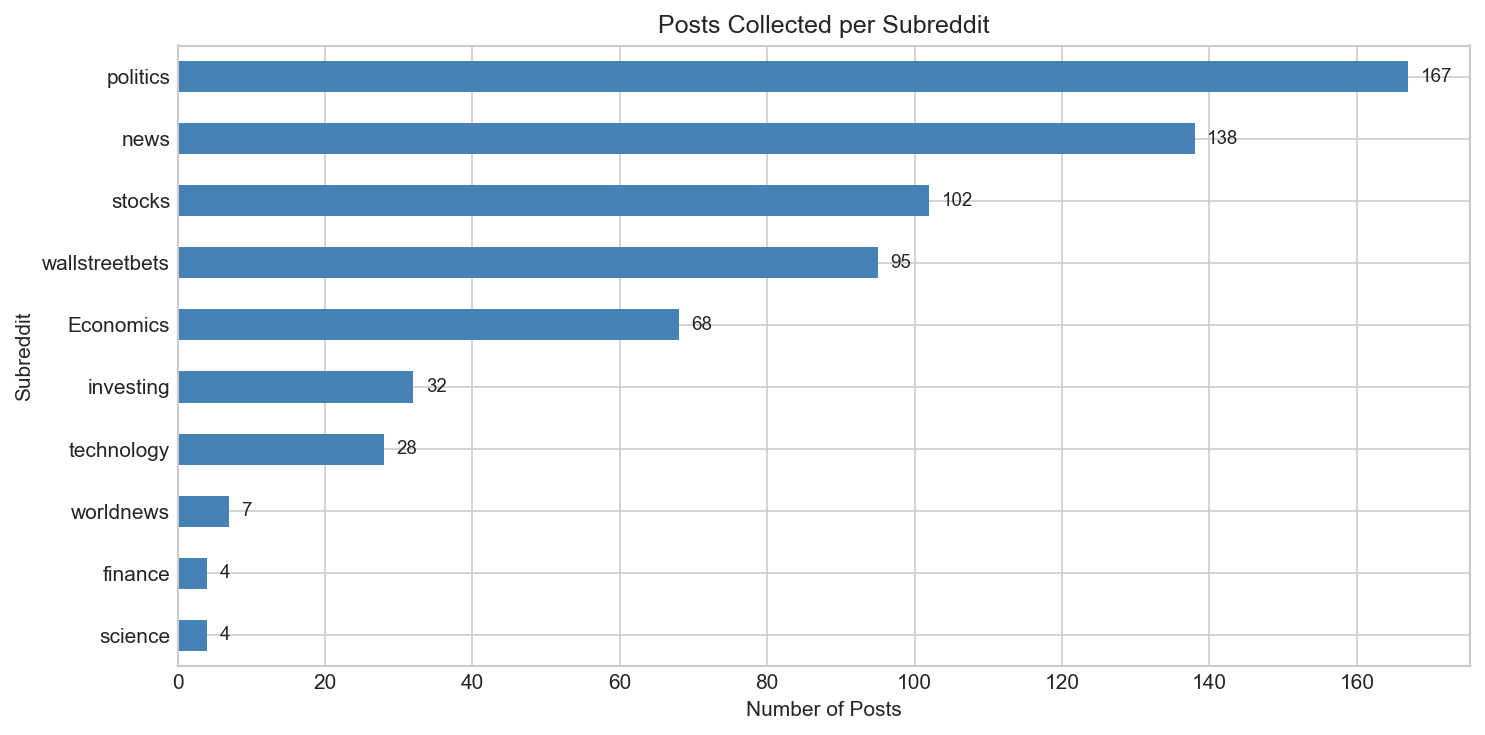

In [4]:
sub_counts = df['subreddit'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sub_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Posts')
ax.set_ylabel('Subreddit')
ax.set_title('Posts Collected per Subreddit')
ax.invert_yaxis()
for i, v in enumerate(sub_counts.values):
    ax.text(v + max(sub_counts) * 0.01, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig1_posts_per_subreddit.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Post Length Distribution

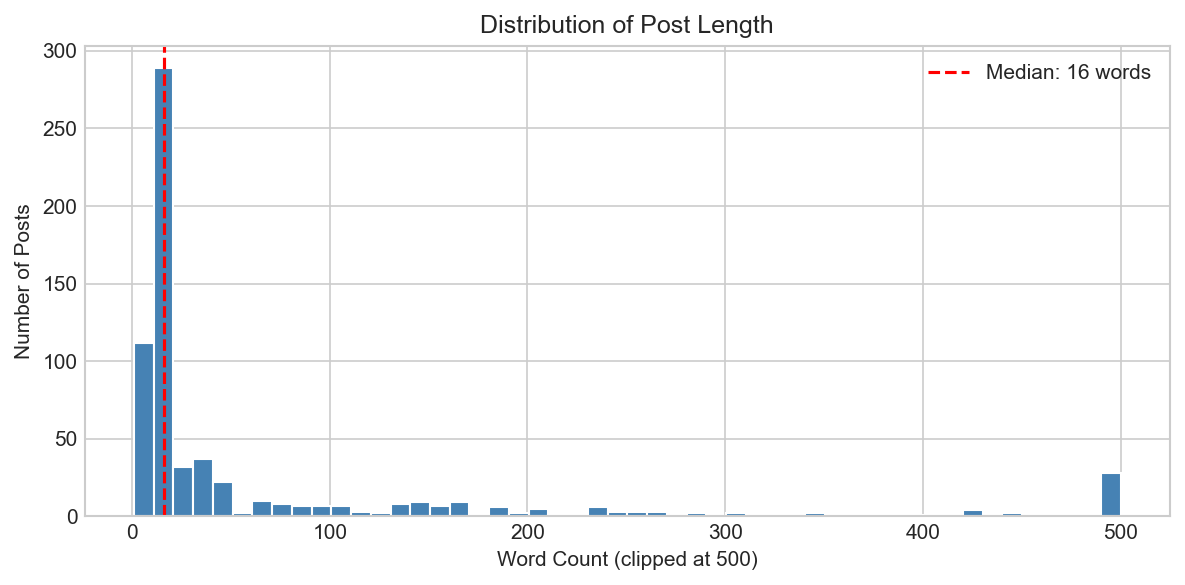

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
df['word_count'].clip(upper=500).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Word Count (clipped at 500)')
ax.set_ylabel('Number of Posts')
ax.set_title('Distribution of Post Length')
ax.axvline(df['word_count'].median(), color='red', linestyle='--',
           label=f"Median: {df['word_count'].median():.0f} words")
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig3_word_count_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Score Distribution

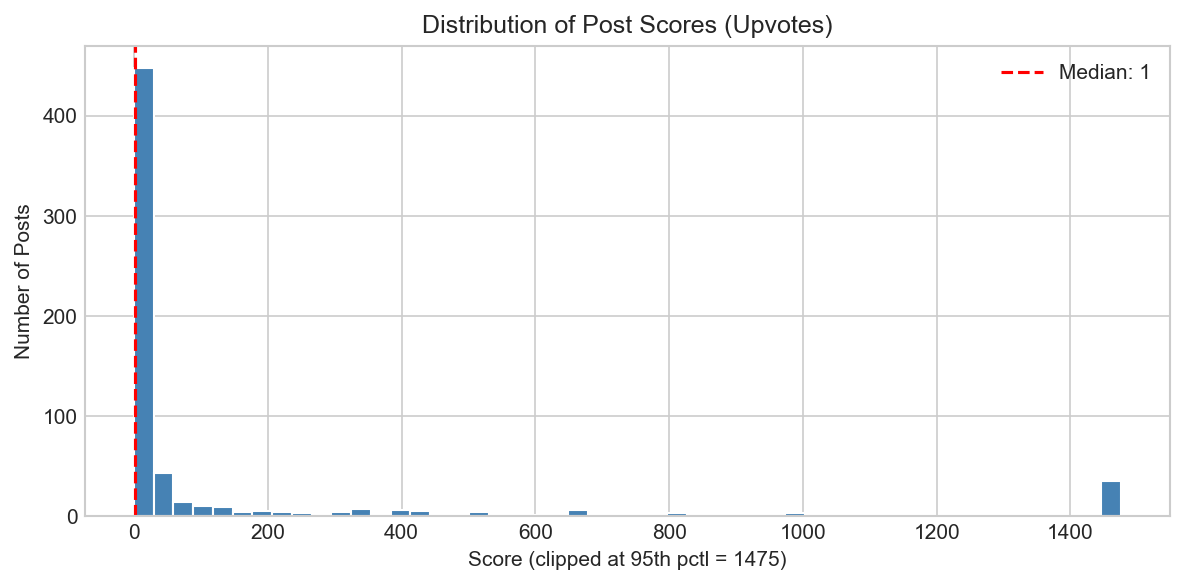

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
upper = df['score'].quantile(0.95)
df['score'].clip(upper=upper).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel(f'Score (clipped at 95th pctl = {upper:.0f})')
ax.set_ylabel('Number of Posts')
ax.set_title('Distribution of Post Scores (Upvotes)')
ax.axvline(df['score'].median(), color='red', linestyle='--',
           label=f"Median: {df['score'].median():.0f}")
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig4_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Text Preprocessing Pipeline

Steps applied:
1. Lowercase
2. Remove URLs
3. Remove non-alphabetic characters
4. Tokenize
5. Remove stopwords (English + domain-specific)
6. Lemmatize
7. Drop posts with ≤3 tokens remaining

In [30]:
import re

STOP_WORDS = set("""
a about above after again against all am an and any are arent as at be because
been before being below between both but by cant cannot could couldnt did
didnt do does doesnt doing dont down during each few for from further get
got had hadnt has hasnt have havent having he her here hers herself him
himself his how if in into is isnt it its itself lets me more most mustnt
my myself no nor not of off on once only or other ought our ours ourselves out
over own same shant she should shouldnt so some such than that the their
theirs them themselves then there these they this those through to too under
until up very was wasnt we were werent what when where which while who whom
why will with wont would wouldnt you your yours yourself yourselves
also like think get one know even really much going well say
http https www com amp removed deleted people thing make want go see still
just new way us many right back need now take time year use two every
made said come put first good may got look can day days says talks
""".split())

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print('Cleaning text...')
df['cleaned_text'] = df['full_text'].apply(clean_text)
df['cleaned_word_count'] = df['cleaned_text'].str.split().str.len()
print('Done.')

Cleaning text...
Done.


In [31]:
# Show before/after example
sample_idx = df[df['selftext'].str.len() > 100].index[0]
print('=== BEFORE CLEANING ===')
print(df.loc[sample_idx, 'full_text'][:500])
print()
print('=== AFTER CLEANING ===')
print(df.loc[sample_idx, 'cleaned_text'][:500])

=== BEFORE CLEANING ===
the Russell 2000 is a grossly overvalued bag of inflated debt obligations while rates are rising and input costs are rising with oil Once upon a time in a shitty town in the mountains.......The Russell 2000 is where the companies that couldn't even get nerd town (Nasdaq) or popular town (SPY) goes to live. its filled with 40% of companies that are unprofitable. The 10 year treasury has now risen SHARPLY from like 4.1 to something like 4.42 as of writing. this was when the russell was at all time

=== AFTER CLEANING ===
russell grossly overvalued bag inflated debt obligations rates rising input costs rising oil upon shitty town mountainsthe russell companies nerd town nasdaq popular town spy goes live filled companies unprofitable treasury risen sharply something writing russell highs since massive private credit debt bomb supposed alleviated rate cut aint happening least fed governor insane cut rates inflationary environment digress recent rate hikes expected cu

In [32]:
# Drop very short posts
before_drop = len(df)
df_clean = df[df['cleaned_word_count'] > 3].copy()

print(f'Posts before filtering: {before_drop}')
print(f'Posts after filtering:  {len(df_clean)}')
print(f'Removed:               {before_drop - len(df_clean)} ({100*(before_drop - len(df_clean))/before_drop:.1f}%)')
print(f'Avg words before:      {df["word_count"].mean():.1f}')
print(f'Avg words after clean: {df_clean["cleaned_word_count"].mean():.1f}')

Posts before filtering: 645
Posts after filtering:  626
Removed:               19 (2.9%)
Avg words before:      77.8
Avg words after clean: 41.3


## 9. Top Words After Preprocessing

Vocabulary size: 6239 unique words
Total tokens:    25879


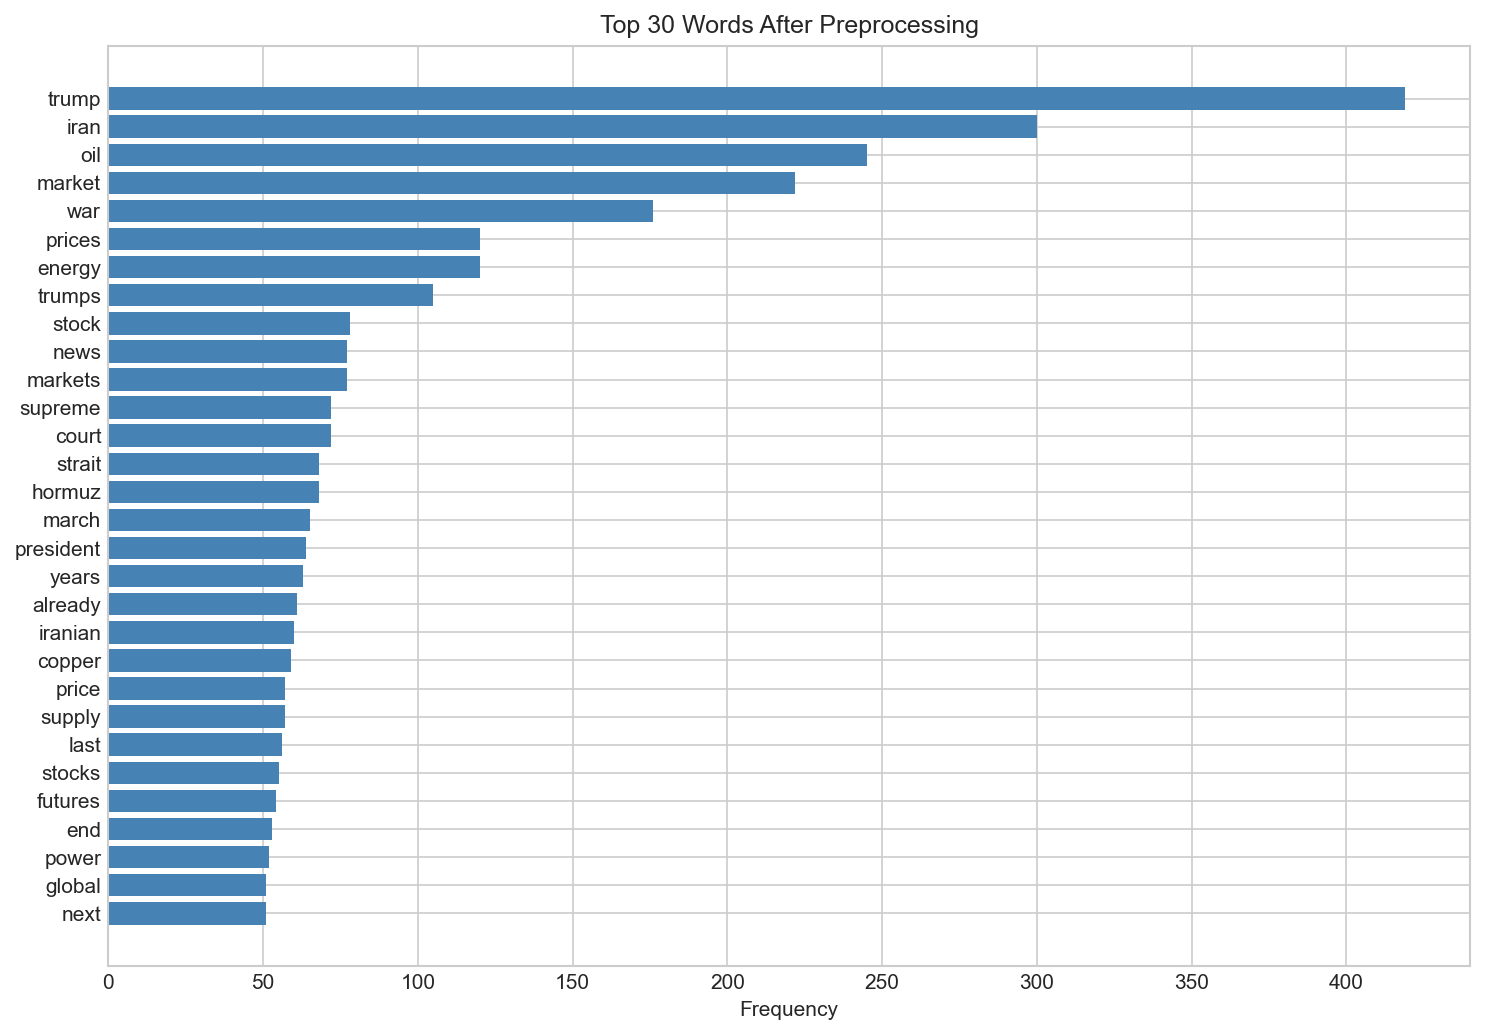

In [33]:
all_words = ' '.join(df_clean['cleaned_text']).split()
word_freq = Counter(all_words).most_common(30)
words, counts = zip(*word_freq)

print(f'Vocabulary size: {len(set(all_words))} unique words')
print(f'Total tokens:    {len(all_words)}')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(words)), counts, color='steelblue')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Words After Preprocessing')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig5_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Top Words by Kalshi Category
We group posts by the Kalshi contract categories they relate to and show the most frequent associated terms.

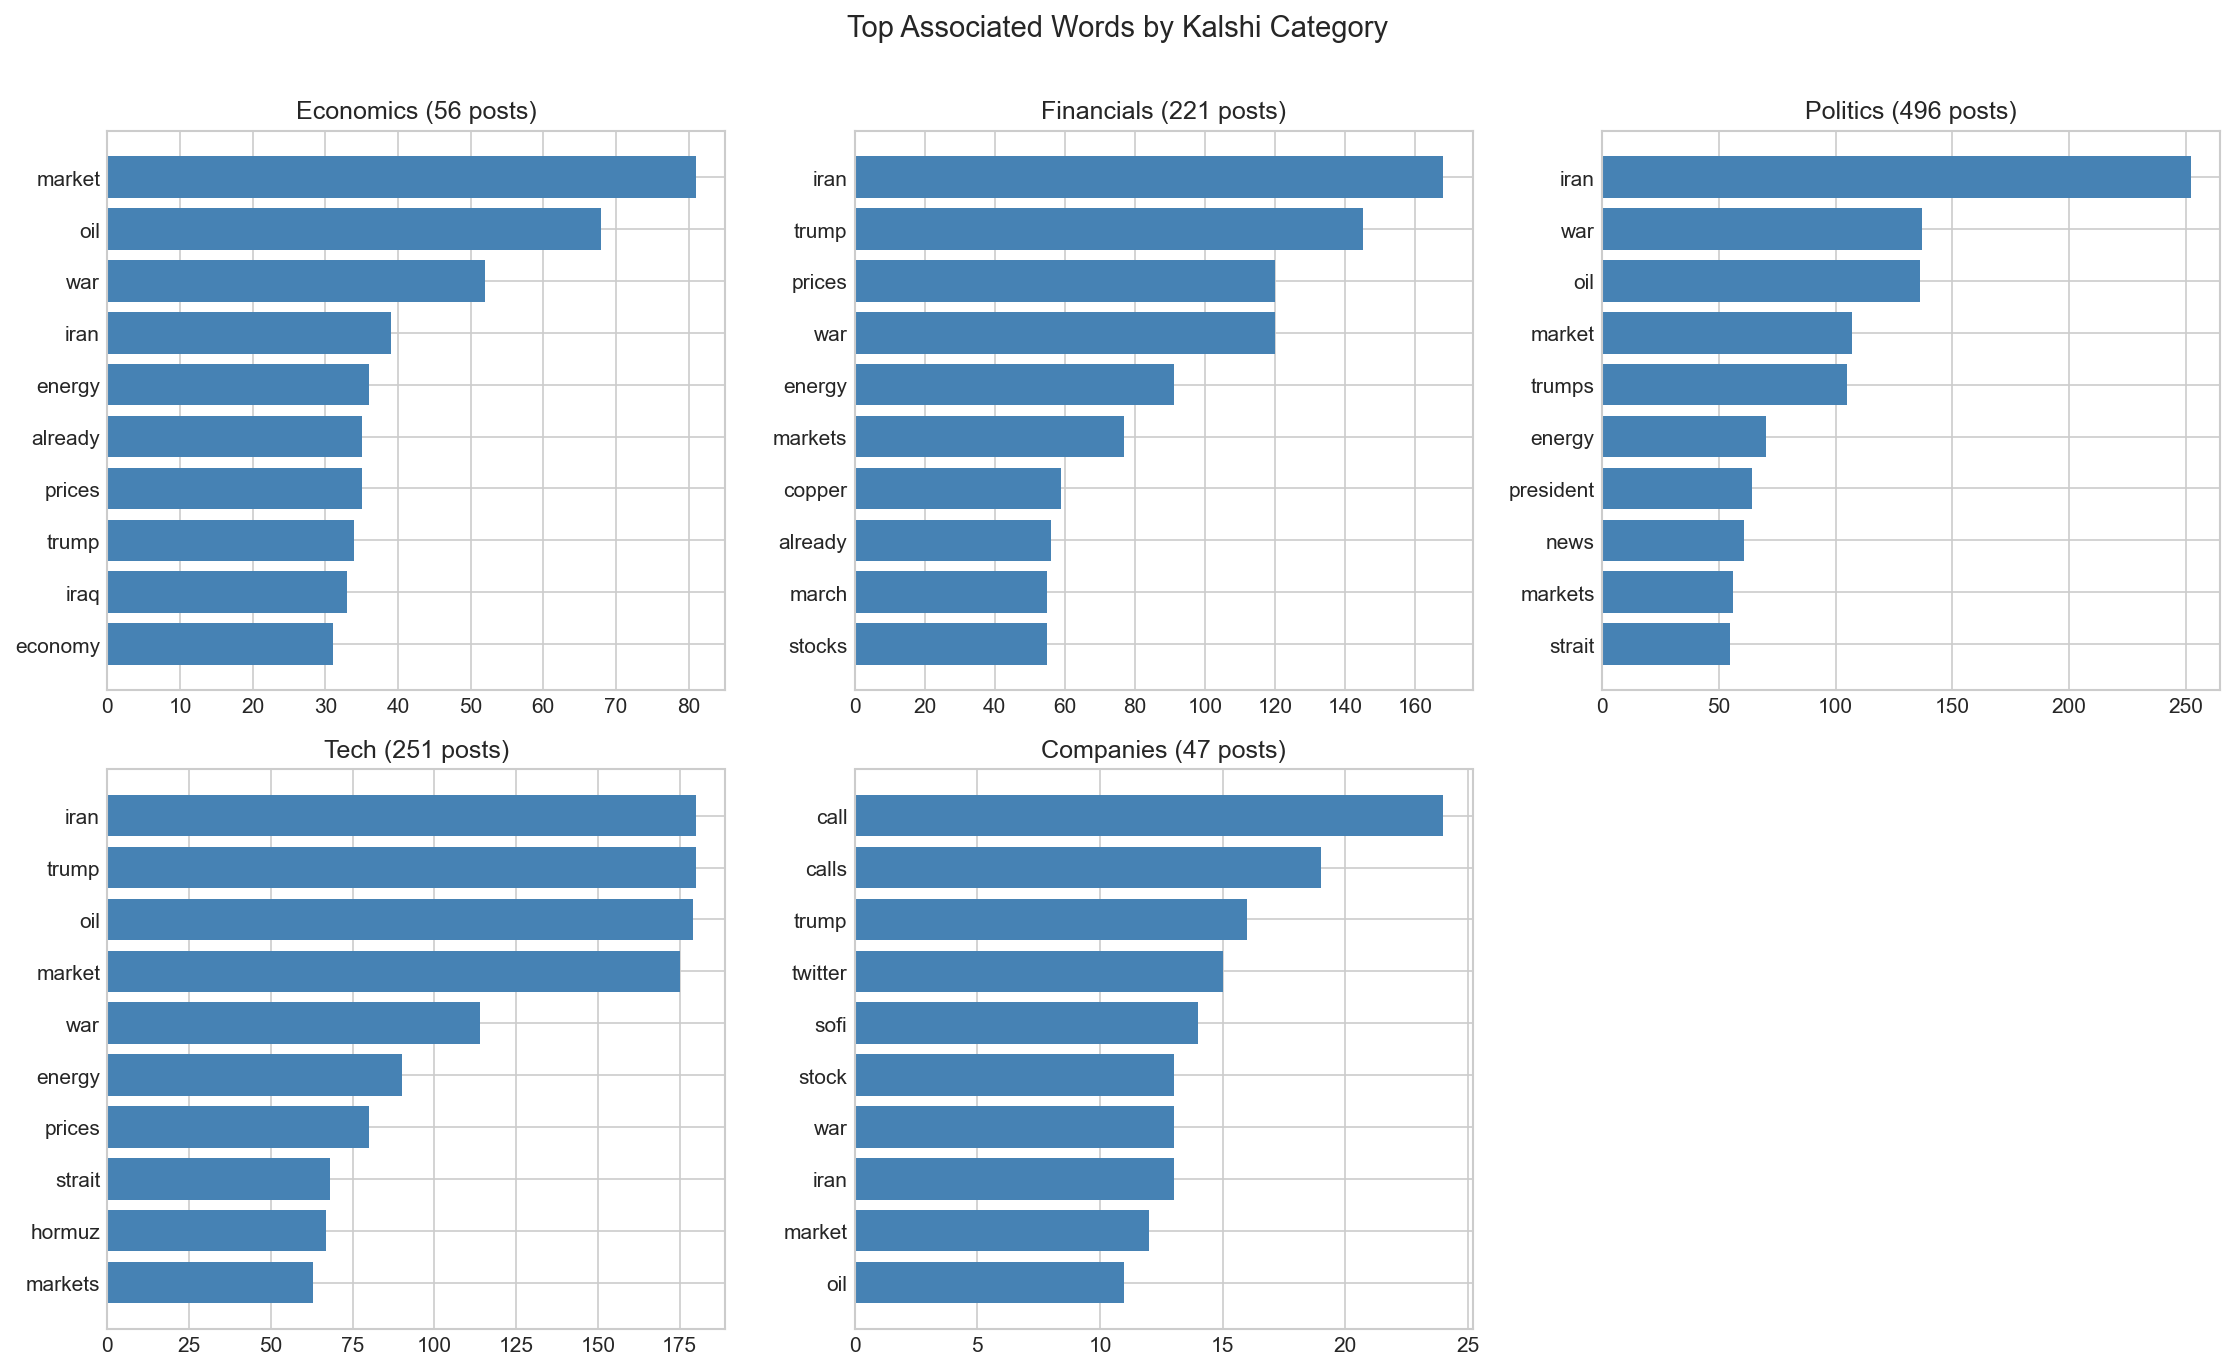

In [34]:
CATEGORY_KEYWORDS = {
    'Economics':  ['fed', 'inflation', 'cpi', 'recession', 'gdp', 'job', 'unemployment', 'housing'],
    'Financials': ['stock', 'market', 'treasury', 'oil', 'price', 'bond'],
    'Politics':   ['trump', 'congress', 'supreme', 'court', 'shutdown', 'election', 'vote', 'poll'],
    'Tech':       ['ai', 'artificial', 'intelligence', 'spacex', 'nasa', 'tech'],
    'Companies':  ['musk', 'elon', 'ipo', 'layoff', 'ceo'],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (category, cat_kw) in enumerate(CATEGORY_KEYWORDS.items()):
    mask = df_clean['cleaned_text'].str.contains('|'.join(cat_kw), case=False, na=False)
    subset = df_clean[mask]

    if len(subset) == 0:
        axes[idx].set_title(f'{category} (no posts)')
        axes[idx].axis('off')
        continue

    cat_words = ' '.join(subset['cleaned_text']).split()
    cat_words = [w for w in cat_words if w not in cat_kw]
    cat_freq = Counter(cat_words).most_common(10)

    if cat_freq:
        w, c = zip(*cat_freq)
        axes[idx].barh(range(len(w)), c, color='steelblue')
        axes[idx].set_yticks(range(len(w)))
        axes[idx].set_yticklabels(w)
        axes[idx].invert_yaxis()
    axes[idx].set_title(f'{category} ({len(subset)} posts)')

# Hide unused subplot
for j in range(len(CATEGORY_KEYWORDS), len(axes)):
    axes[j].axis('off')

plt.suptitle('Top Associated Words by Kalshi Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig6_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Category Coverage Summary
How many posts fall into each Kalshi category — this demonstrates dataset adequacy.

In [35]:
category_counts = {}
for category, cat_kw in CATEGORY_KEYWORDS.items():
    mask = df_clean['cleaned_text'].str.contains('|'.join(cat_kw), case=False, na=False)
    category_counts[category] = mask.sum()

cat_df = pd.DataFrame(list(category_counts.items()), columns=['Category', 'Post Count'])
cat_df = cat_df.sort_values('Post Count', ascending=False)
cat_df['% of Corpus'] = (100 * cat_df['Post Count'] / len(df_clean)).round(1)
print(cat_df.to_string(index=False))
print(f'\nNote: Posts can belong to multiple categories.')

  Category  Post Count  % of Corpus
  Politics         496         79.2
      Tech         251         40.1
Financials         221         35.3
 Economics          56          8.9
 Companies          47          7.5

Note: Posts can belong to multiple categories.


---
## 12. Save Preprocessed Data

In [36]:
output_path = '../data/processed/reddit_posts_cleaned.csv'
df_clean.to_csv(output_path, index=False)

file_size = os.path.getsize(output_path) / (1024 * 1024)
print(f'Saved {len(df_clean)} cleaned posts to {output_path} ({file_size:.1f} MB)')

Saved 626 cleaned posts to ../data/processed/reddit_posts_cleaned.csv (0.9 MB)


## 13. Summary for Milestone Report
Copy these stats directly into your report.

In [37]:
print('=' * 60)
print('MILESTONE REPORT STATS')
print('=' * 60)
print(f'Raw posts collected:       {before_drop}')
print(f'Posts after cleaning:      {len(df_clean)}')
print(f'Posts removed:             {before_drop - len(df_clean)}')
print(f'Unique subreddits:         {df_clean["subreddit"].nunique()}')
print(f'Date range:                {df_clean["created_date"].min().strftime("%Y-%m-%d")} to {df_clean["created_date"].max().strftime("%Y-%m-%d")}')
print(f'Avg words (raw):           {df["word_count"].mean():.1f}')
print(f'Avg words (cleaned):       {df_clean["cleaned_word_count"].mean():.1f}')
print(f'Vocabulary size:           {len(set(all_words))}')
print(f'Total tokens:              {len(all_words)}')
print()
print('Figures saved to:          ../reports/figures/')
print('Cleaned data saved to:     ../data/processed/reddit_posts_cleaned.csv')
print()
print('Figures generated:')
for f in sorted(os.listdir(FIGURE_DIR)):
    if f.endswith('.png'):
        print(f'  - {f}')

MILESTONE REPORT STATS
Raw posts collected:       645
Posts after cleaning:      626
Posts removed:             19
Unique subreddits:         10
Date range:                2026-03-22 to 2026-03-28
Avg words (raw):           77.8
Avg words (cleaned):       41.3
Vocabulary size:           6239
Total tokens:              25879

Figures saved to:          ../reports/figures/
Cleaned data saved to:     ../data/processed/reddit_posts_cleaned.csv

Figures generated:
  - fig1_posts_per_subreddit.png
  - fig2_volume_over_time.png
  - fig3_word_count_dist.png
  - fig4_score_dist.png
  - fig5_top_words.png
  - fig6_words_by_category.png
